In [1]:
import os
import yaml 
import gc
import matplotlib.pyplot as plt


In [2]:
from generic.distributed import Distributed
distributed= Distributed.get_instance()

# individually

## Test IO

In [3]:
from data.utils_data import ModelDataConfig, ObsDataConfig, ConditionDataConfig
from preprocessing.preprocessing import *


from preprocessing.utils_preprocessing import *
from data.datasets import *

In [4]:
from data.dataloader import *

In [5]:
expe_dir = Path("/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/cccma_PPP_test")
os.environ["GLOBAL_EXP_DIR"] = str(expe_dir)

os.environ["GLOBAL_CHECKPOINT_DIR"] = os.path.join(expe_dir, "training_checkpoints")
os.environ["GLOBAL_FIGURES_DIR"] = os.path.join(expe_dir, "figures")
os.environ["GLOBAL_LOG_DIR"] = os.path.join(expe_dir, "logs")

checkpoint_dir = os.path.join(expe_dir, "training_checkpoints")
figures_dir = os.path.join(expe_dir, "figures")
log_dir = os.path.join(expe_dir, "logs")

In [7]:
model_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/forecast_data'
observation_path = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/tas/observations'
input_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'anomalies') ]) #,PreprocessingStepSelector(name = 'oceannanremover')])
target_pp = PreprocessingPipeline([PreprocessingStepSelector(name = 'standardizer')]) #,PreprocessingStepSelector(name = 'oceannanremover')])
name = ['tas']

model = ModelDataConfig(paths = model_path, names = name, preprocessing_pipeline=input_pp, concat_dim='year')
observation = ObsDataConfig(paths = observation_path, names = name, preprocessing_pipeline=target_pp, concat_dim='year', rename_dict={'lead_time' : 'month'})

In [8]:
config_ds = XArrayDatasetConfig(model=model, observation= observation, time_features=['year'], condition_method='ensemble_mean')

/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/data/datasets.py:40: UserWarning: model and observation data do not have the same latitudes cooridnates.
  warnings.warn(f'model and observation data do not have the same latitudes cooridnates.')
/fs/homeu3/eccc/crd/cccma/rpg002/CCCma_PPP/data/datasets.py:42: UserWarning: model and observation data do not have the same longitudes cooridnates.
  warnings.warn(f'model and observation data do not have the same longitudes cooridnates.')


#### test dataset config

In [ ]:
# config_ds.model.paths

In [ ]:
# config_ds.available_train_time


In [ ]:
# print('common time: ', config_ds.get_common_time)
# print('available train time: ', config_ds.available_train_time)

In [9]:
## test saving:
config_ds._fit_preprocessors(train_years = [1980,2000])
## test loading:
# config_ds._load_fitted_preprocessors(load_dir= '.')

In [ ]:
# config_ds.model.preprocessing_pipeline.get_preprocessors('anomalies').mean
# 

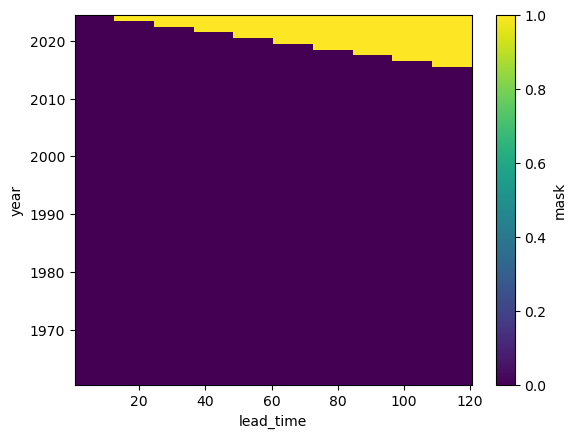

In [10]:


def _create_train_mask(years : list | xr.DataArray , lead_times: list | xr.DataArray |int , exclude_idx=0):

    if isinstance(lead_times , int):
        lead_times = np.arange(1, lead_times+1)

    mask = np.full((len(years), len(lead_times)), False, dtype=bool)
    x = np.arange(0, 12*mask.shape[0], 12)   
    y = np.arange(1, mask.shape[1] + 1)
    idx_array = x[..., None] + y
    # mask[idx_array >= idx_array[-1, exclude_idx + 12]] = True
    mask[idx_array > idx_array[-1, exclude_idx + 11]] = True

    return xr.DataArray(
        mask,
        dims=('year', 'lead_time'),
        coords={'year': years, 'lead_time': lead_times},
        name="mask"
    )

mask = _create_train_mask(config_ds.available_train_time, config_ds.num_model_lead_months)
mask.plot()

In [11]:
# config_ds.get_common_time

In [12]:
dataset = config_ds.build(years =[1980,2000] , mask = None, return_metadata = False)

In [13]:
dataset._autoencoding_input

True

In [18]:
dataset[0]['target'].shape

torch.Size([1, 64, 129])

In [ ]:
# dataset.mask

In [ ]:
# dataset = config_ds.build(config_ds.available_train_time, mask = mask)

#### test dataloader config

In [ ]:
trainlodaer_config = TrainDataloaderConfig(config_ds,train_years = [1980,1982], batch_size = 10, num_data_workers=0)

In [ ]:
trainlodaer_config.setup_distributed(distributed)
train_loader = trainlodaer_config.build_train_loader(return_spatial_mask=False)

In [ ]:
# len(train_loader.dataset)

In [ ]:
# train_loader.dataset[0]

In [ ]:
data = next(iter(train_loader))

In [ ]:
# train_loader.dataset.config.target_info.coords['lat'].size

## test losses

In [ ]:
from loss.utils_loss import *
from loss.loss import *


In [ ]:
loss_config = LosspipelineConfig(
    loss_pipeline = [ LossStepConfig(name = 'mse' , args =  {'low_ress_kernel_size':3})],
    reduction='sum'
    # loss_weights= [0.2,0.8] 
)

In [ ]:
weights = config_ds.get_weights()

In [ ]:
weights

In [ ]:
loss = loss_config.build(weights, num_output_dimensions=1)

In [ ]:
loss.pipeline

In [ ]:
loss.weights

## test optimizer

In [ ]:
from core.optimization import OptimizerConfig, LRSchedulerConfig 

In [ ]:
scheculer_config = LRSchedulerConfig()
oprimConfig = OptimizerConfig(lr_scheduler_config  = scheculer_config)

In [ ]:
# oprimConfig

## test module selectors

In [ ]:
from core.selectors import *
from core.deterministic_module import *
from core.cVAE_module import *
from models.mlp_models import *

In [ ]:
model_conf = cVAEModelSelector(type = 'MLP' , args = {'encoder_hidden_dims' : [3000,3000,3000], 
                                                                'latent_size' : 10,
                                                                'decoder_hidden_dims': [3000,3000,3000, 5000],
                                                                'condition_embedding_dims' :  [3000,3000,10],
                                                                'condition_dependant_latent': True,
                                                                'condemb_to_decoder':  True,
                                                                'batch_normalization' : True,
                                                                'dropout_rate': 0.5,
                                                                'init_method' :  'xavier'})
                                                                                        

In [ ]:
model_conf.args

In [ ]:
flow_ = NormalizedFlowConfig([FlowSelector(type = 'RealNVP',
                                           args = { 'hidden_dim' : 5} ),
                                FlowSelector(type = 'MAF',
                                           args = { 'hidden_dim' : 5} )])

In [ ]:
_config  = {'ModelConfig'  : model_conf, 
            'min_posterior_variance' :  2,
                'prior_flow_config' : flow_,
            'combined_CGCN_weight' :  0.1}

In [ ]:
cVAE_config = ModuleSelector(type = 'cVAE',
                          config = _config)

In [ ]:
cVAE_config

In [ ]:
cVAE_ = cVAE_config.build_module(train_loader.input_shape,train_loader.target_shape, train_loader.added_features_dim)

In [ ]:
train_loader.input_shape

In [ ]:
cVAE_

In [ ]:
cVAE_.init_loss_function(loss)

In [ ]:
cVAE_  = cVAE_.to(distributed.device)

In [ ]:
optimizer = oprimConfig.build(module =cVAE_, num_batches=len(train_loader), total_epochs=1)

## trainer test

In [ ]:
from core.trainer import *

In [ ]:

# for path in (checkpoint_dir , figures_dir,log_dir ):
#     if distributed.is_root():
#         os.makedirs(path, exist_ok=True)



In [ ]:
from loss.kld import BetaAnnealing
beta = BetaAnnealing(beta = 0.001, num_epoch_to_warmup=10)

In [ ]:
trainer_conf = TrainerConfig(
    beta_finder = beta,
    earlystoppingbuffer = 10,
    gradient_accumulation_steps =2,
    mixed_precision = True )

In [ ]:
trainer = trainer_conf.build(train_data_loader=train_loader,
                             validation_data_loader=None,
                             optimization=optimizer,
                             module=cVAE_,
                             epochs = 3)

In [ ]:
trainer.setup_distributed(distributed=distributed,
                          logger = None, 
                          log_every_n_epochs = 2)

In [ ]:
trainer.train()

# train.py

In [ ]:
def prepare_config(path: str) -> dict:
    """Get config and update with possible dotlist override."""
    with open(path) as f:
        data = yaml.safe_load(f)
    return data


In [ ]:
yaml_config = '/home/rpg002/CCCma_PPP/train_config.yaml'
config_data = prepare_config(yaml_config)

In [ ]:
config_data['train_loader']['train_years']

In [ ]:
from train.train_configs import *
import dacite

In [ ]:
config = dacite.from_dict(data_class=TrainConfig, data=config_data, config=dacite.Config(strict=True))


In [ ]:
config

In [ ]:
config.set_random_seed()

In [ ]:
from generic.logger import setup_logger


In [ ]:
    logger = setup_logger(name = 'training',
                          log_dir = config.log_dir )

In [ ]:
config.log_dir

In [ ]:
    if distributed.is_root():
        logger.info('Setting up directories ...')

In [ ]:
config.prepare_directory(distributed) 

In [ ]:
    if distributed.is_root():
        logger.info('Building trainer ...')    

In [ ]:
config.train_loader.setup_distributed(distributed)

In [ ]:
    train_loader = config.train_loader.build_train_loader()
    validation_loader =  config.train_loader.build_validation_loader()

In [ ]:
    num_train_batches = len(train_loader)
    input_shape = train_loader.input_shape
    output_shape = train_loader.target_shape
    added_features_dim = train_loader.added_features_dim

In [ ]:
num_train_batches

In [ ]:
input_shape

In [ ]:
output_shape

In [ ]:
added_features_dim

In [ ]:
weights = train_loader.get_weights(config.weights)

In [ ]:
config.experiment_dir

In [ ]:
    module = config.module.build_module(  input_shape = input_shape,
                                        output_shape = output_shape,
                                        added_features_dim = added_features_dim)

In [ ]:
 module  = module.to(distributed.device)

In [ ]:
    if distributed.distributed:
        module = torch.nn.parallel.DistributedDataParallel(module, device_ids=[distributed.local_rank], output_device=distributed.local_rank, find_unused_parameters=False)


In [ ]:
    reconstruction_loss = config.losspipeline.build(weights=weights, num_output_dimensions= getattr(module.model, 'NUM_OUTPUT_DIMS', None ) or len(output_shape))

    module.init_loss_function(reconstruction_loss)


In [ ]:
    optimizer = config.optimization.build(module, num_train_batches, config.epochs)


In [ ]:
    trainer = config.trainer.build(
              train_data_loader  = train_loader , 
              validation_data_loader = validation_loader, 
              module = module,
              optimization = optimizer,
              epochs = config.epochs)

In [ ]:
    trainer.setup_distributed(  distributed = distributed ,
                    logger = logger,
                    log_every_n_epochs = config.log_every_n_epochs,
                    save_checkpoint =  config.save_checkpoint )

In [ ]:
trainer.train()